# 🔥 PHASE 1: Problem Statement (VERY IMPORTANT)



### 🎯 Business Problem
The Fastag system is designed for automated toll payments. However, system loopholes allow for:
* **Underpayment:** Paying less than the required amount.
* **Payment Avoidance:** Bypassing the transaction entirely.
* **Category/Lane Misuse:** Misrepresenting vehicle types to pay lower rates.

> **Impact:** This leads to significant revenue loss and high volumes of fraudulent transactions.

---

### 🎯 Objective
Build a **Machine Learning model** capable of predicting transaction validity:
* **Fraud (1)**
* **Not Fraud (0)**

**Target Variable:** `Fraud_indicator`  
*(Mapped as: Fraud → 1, Not Fraud → 0)*

---

### 🎯 Type of Problem
👉 **Supervised Classification Problem**

---

### 🎯 Key Challenges
* **Data Gaps:** Missing values (e.g., empty `FastagID`).
* **Categorical Encoding:** Managing high-cardinality features.
* **Geospatial Data:** Transforming the `Location` column into usable features.
* **Class Imbalance:** Fraud cases are typically much rarer than legitimate ones.
* **Real-time Requirements:** High-speed prediction for toll lane processing.

---

### 🎯 Success Metric (VERY IMPORTANT 🚨)
In fraud detection, the cost of a "False Negative" (missing fraud) outweighs a "False Positive."

| Metric | Priority | Status |
| :--- | :--- | :--- |
| **Recall** | **MOST IMPORTANT** ✅ | **Primary Focus:** Missing fraud = direct revenue loss 💸 |
| Precision | Moderate | Balancing customer experience vs. security. |
| F1-score | High | Balancing Precision and Recall. |
| ROC-AUC | High | Measuring overall model discrimination. |
| Accuracy | **NOT USEFUL** ❌ | Misleading due to class imbalance. |

# 🔥 PHASE 2: EDA (Exploratory Data Analysis)

In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [230]:
df = pd.read_csv('FastagFraudDetection.csv')

df.head()

,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Vehicle_Plate_Number,Fraud_indicator
0,1,1/6/2023 11:20,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,KA11AB1234,Fraud
1,2,1/7/2023 14:55,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,KA66CD5678,Fraud
2,3,1/8/2023 18:25,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,KA88EF9012,Not Fraud
3,4,1/9/2023 2:05,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,KA11GH3456,Fraud
4,5,1/10/2023 6:35,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,KA44IJ6789,Fraud


In [231]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Transaction_ID         5000 non-null   int64 
 1   Timestamp              5000 non-null   object
 2   Vehicle_Type           5000 non-null   object
 3   FastagID               4451 non-null   object
 4   TollBoothID            5000 non-null   object
 5   Lane_Type              5000 non-null   object
 6   Vehicle_Dimensions     5000 non-null   object
 7   Transaction_Amount     5000 non-null   int64 
 8   Amount_paid            5000 non-null   int64 
 9   Geographical_Location  5000 non-null   object
 10  Vehicle_Speed          5000 non-null   int64 
 11  Vehicle_Plate_Number   5000 non-null   object
 12  Fraud_indicator        5000 non-null   object
dtypes: int64(4), object(9)
memory usage: 507.9+ KB
None


In [232]:
print(f"Shape of the dataset: {df.shape}")


Shape of the dataset: (5000, 13)


In [233]:
df.describe()

,Transaction_ID,Transaction_Amount,Amount_paid,Vehicle_Speed
count,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,161.06200,141.261000,67.851200
std,1443.520003,112.44995,106.480996,16.597547
min,1.000000,0.00000,0.000000,10.000000
25%,1250.750000,100.00000,90.000000,54.000000
50%,2500.500000,130.00000,120.000000,67.000000
75%,3750.250000,290.00000,160.000000,82.000000
max,5000.000000,350.00000,350.000000,118.000000


In [234]:
print(f"Columns in the dataset: {df.columns}")


Columns in the dataset: Index(['Transaction_ID', 'Timestamp', 'Vehicle_Type', 'FastagID',
       'TollBoothID', 'Lane_Type', 'Vehicle_Dimensions', 'Transaction_Amount',
       'Amount_paid', 'Geographical_Location', 'Vehicle_Speed',
       'Vehicle_Plate_Number', 'Fraud_indicator'],
      dtype='object')


In [235]:
print(f"Data types of the columns:\n{df.dtypes}")


Data types of the columns:
Transaction_ID            int64
Timestamp                object
Vehicle_Type             object
FastagID                 object
TollBoothID              object
Lane_Type                object
Vehicle_Dimensions       object
Transaction_Amount        int64
Amount_paid               int64
Geographical_Location    object
Vehicle_Speed             int64
Vehicle_Plate_Number     object
Fraud_indicator          object
dtype: object


In [236]:
print(f"Number of missing values in each column:\n{df.isnull().sum()}")

Number of missing values in each column:
Transaction_ID             0
Timestamp                  0
Vehicle_Type               0
FastagID                 549
TollBoothID                0
Lane_Type                  0
Vehicle_Dimensions         0
Transaction_Amount         0
Amount_paid                0
Geographical_Location      0
Vehicle_Speed              0
Vehicle_Plate_Number       0
Fraud_indicator            0
dtype: int64


## Target Variable Analysis

In [237]:
df['Fraud_indicator'].value_counts()

Fraud_indicator
Not Fraud    4017
Fraud         983
Name: count, dtype: int64

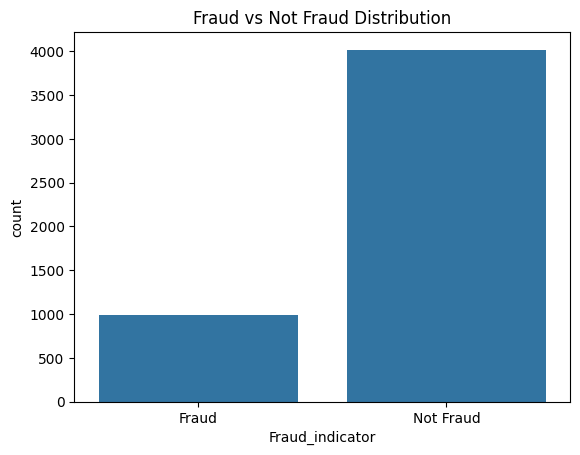

In [238]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Fraud_indicator', data=df)
plt.title("Fraud vs Not Fraud Distribution")
plt.show()

## Missing Value Analysis

In [239]:
pd.crosstab(df['FastagID'].isnull(), df['Fraud_indicator'])

Fraud_indicator,Fraud,Not Fraud
FastagID,,
False,983,3468
True,0,549


## Create Important Feature

In [240]:
# df['Amount_diff'] = df['Transaction_Amount'] - df['Amount_paid']

df.head()

,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Vehicle_Plate_Number,Fraud_indicator
0,1,1/6/2023 11:20,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,KA11AB1234,Fraud
1,2,1/7/2023 14:55,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,KA66CD5678,Fraud
2,3,1/8/2023 18:25,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,KA88EF9012,Not Fraud
3,4,1/9/2023 2:05,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,KA11GH3456,Fraud
4,5,1/10/2023 6:35,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,KA44IJ6789,Fraud


In [241]:
# sns.boxplot(x='Fraud_indicator', y='Amount_diff', data=df)
# plt.title("Amount Difference vs Fraud")
# plt.show()

## Vehicle Type vs Fraud

In [242]:
pd.crosstab(df['Vehicle_Type'], df['Fraud_indicator'])

Fraud_indicator,Fraud,Not Fraud
Vehicle_Type,,
Bus,177,539
Car,122,592
Motorcycle,0,714
SUV,184,530
Sedan,161,553
Truck,158,556
Van,181,533


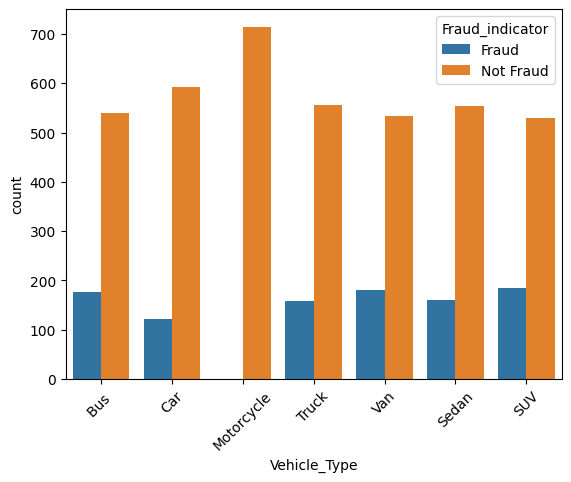

In [243]:
sns.countplot(x='Vehicle_Type', hue='Fraud_indicator', data=df)
plt.xticks(rotation=45)
plt.show()

## Lane Type vs Fraud

In [244]:
pd.crosstab(df['Lane_Type'], df['Fraud_indicator'])

Fraud_indicator,Fraud,Not Fraud
Lane_Type,,
Express,490,1652
Regular,493,2365


## Speed vs Fraud

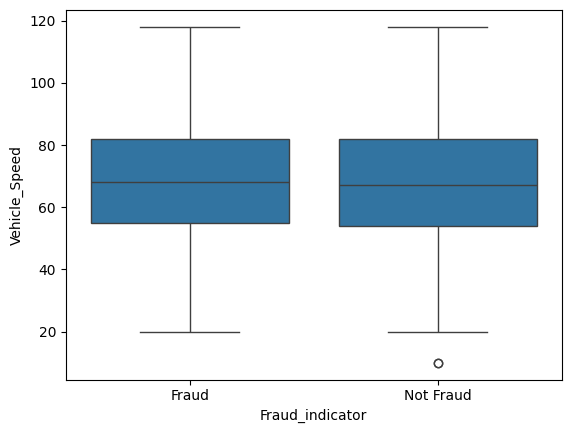

In [245]:
sns.boxplot(x='Fraud_indicator', y='Vehicle_Speed', data=df)
plt.show()

## Correlation (Numerical Only)

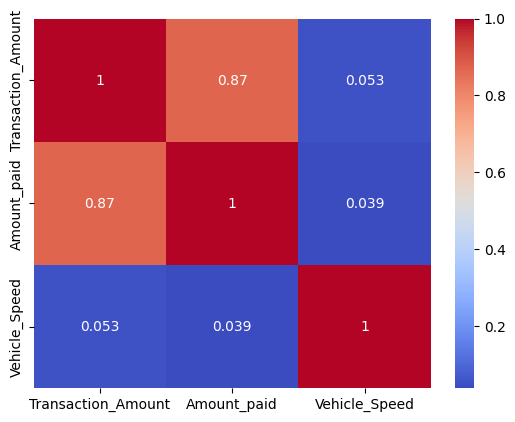

In [246]:
corr = df[['Transaction_Amount', 'Amount_paid', 'Vehicle_Speed']].corr()
# corr = df[['Transaction_Amount', 'Amount_paid', 'Vehicle_Speed', 'Amount_diff']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

## EDA — FINAL INSIGHTS (CRITICAL 🚨)



### ✅ 1. Target Distribution
Based on the initial data analysis:
* **Fraud:** ~983 instances
* **Not Fraud:** ~4017 instances

> **Insight:** The dataset is **imbalanced**. Fraud cases represent only about **20%** of the total data. We must account for this during model training (e.g., using stratified splitting or oversampling).

---

### ✅ 2. FastagID Analysis (The "Motorcycle" Pattern)
Our crosstab reveals a significant heuristic:
* **FastagID is NULL** $\rightarrow$ 0 Fraud | 549 Not Fraud

> **Insight (IMPORTANT):** Missing `FastagID` correlates perfectly with **Motorcycles**. Since motorcycles generally don't require Fastags or pay tolls, they are labeled as "Not Fraud." 
> **Warning:** This is a structural pattern, not "behavioral" fraud. The model might overfit on this "leakage."

---

### ✅ 3. Amount Difference (The "Golden" Feature 🔥)
Analysis of the `Amount_diff` (Transaction Amount - Amount Paid):
* **Fraud:** High `Amount_diff`
* **Not Fraud:** `Amount_diff` $\approx$ 0

> **Insight:** This is the **strongest predictor**. It is a direct indicator of fraud where the system expects one value but receives another.

---

### ✅ 4. Vehicle & Lane Insights
* **Vehicle Type:** Motorcycles show 0% fraud (perfect separator), while other vehicles show mixed behavior.
* **Lane Type:** **Express Lanes** show a higher frequency of fraudulent transactions compared to Regular Lanes.

> **Insight:** Fraudsters seem to prefer Express lanes, possibly to exploit faster processing or specific sensor vulnerabilities.

---

### ✅ 5. Speed & Correlation
* **Speed:** Boxplots show no strong separation between classes. It is currently a **weak feature**.
* **Correlation:** `Transaction_Amount` and `Amount_paid` are highly correlated ($r \approx 0.87$).

> **Insight:** To avoid multi-collinearity, `Amount_diff` is a much more powerful and independent signal than the raw amount columns.

---

### ⚠️ STRATEGIC DECISION (Data Scientist Perspective)

**The Problem:**
`Motorcycle` status and `FastagID` nulls essentially "leak" the label (they are never fraud), which makes the classification task too easy but less robust for other vehicle types.

**The Solution:**
1. **Keep the data:** It represents the realistic flow of toll traffic.
2. **Feature Selection:** We will eventually **drop `FastagID`** to prevent the model from simply memorizing ID presence.
3. **Engineered Focus:** We will let the model prioritize `Amount_diff` and `Vehicle_Type` to learn actual fraudulent patterns.

# 🔥 PHASE 3: DATA PREPROCESSING

In [247]:
df.head()

,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Vehicle_Plate_Number,Fraud_indicator
0,1,1/6/2023 11:20,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,KA11AB1234,Fraud
1,2,1/7/2023 14:55,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,KA66CD5678,Fraud
2,3,1/8/2023 18:25,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,KA88EF9012,Not Fraud
3,4,1/9/2023 2:05,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,KA11GH3456,Fraud
4,5,1/10/2023 6:35,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,KA44IJ6789,Fraud


## Drop Irrelevant Columns

In [248]:
df.drop([
    'Transaction_ID',
    'Vehicle_Plate_Number',
    'FastagID'
], axis=1, inplace=True)

In [249]:
df.head()

,Timestamp,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Fraud_indicator
0,1/6/2023 11:20,Bus,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,Fraud
1,1/7/2023 14:55,Car,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,Fraud
2,1/8/2023 18:25,Motorcycle,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,Not Fraud
3,1/9/2023 2:05,Truck,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,Fraud
4,1/10/2023 6:35,Van,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,Fraud


## Convert Timestamp

In [250]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.head()

,Timestamp,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Fraud_indicator
0,2023-01-06 11:20:00,Bus,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,Fraud
1,2023-01-07 14:55:00,Car,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,Fraud
2,2023-01-08 18:25:00,Motorcycle,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,Not Fraud
3,2023-01-09 02:05:00,Truck,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,Fraud
4,2023-01-10 06:35:00,Van,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,Fraud


In [251]:
df['Hour'] = df['Timestamp'].dt.hour
df['Day'] = df['Timestamp'].dt.day
df['Month'] = df['Timestamp'].dt.month
df.head()

,Timestamp,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Fraud_indicator,Hour,Day,Month
0,2023-01-06 11:20:00,Bus,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,Fraud,11,6,1
1,2023-01-07 14:55:00,Car,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,Fraud,14,7,1
2,2023-01-08 18:25:00,Motorcycle,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,Not Fraud,18,8,1
3,2023-01-09 02:05:00,Truck,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,Fraud,2,9,1
4,2023-01-10 06:35:00,Van,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,Fraud,6,10,1


In [252]:
df.drop('Timestamp', axis=1, inplace=True)
df.head()

,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Fraud_indicator,Hour,Day,Month
0,Bus,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,Fraud,11,6,1
1,Car,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,Fraud,14,7,1
2,Motorcycle,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,Not Fraud,18,8,1
3,Truck,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,Fraud,2,9,1
4,Van,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,Fraud,6,10,1


In [253]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Vehicle_Type           5000 non-null   object
 1   TollBoothID            5000 non-null   object
 2   Lane_Type              5000 non-null   object
 3   Vehicle_Dimensions     5000 non-null   object
 4   Transaction_Amount     5000 non-null   int64 
 5   Amount_paid            5000 non-null   int64 
 6   Geographical_Location  5000 non-null   object
 7   Vehicle_Speed          5000 non-null   int64 
 8   Fraud_indicator        5000 non-null   object
 9   Hour                   5000 non-null   int32 
 10  Day                    5000 non-null   int32 
 11  Month                  5000 non-null   int32 
dtypes: int32(3), int64(3), object(6)
memory usage: 410.3+ KB


## Handle Geographical Location

In [254]:
df[['Latitude', 'Longitude']] = df['Geographical_Location'].str.split(',', expand=True)

df['Latitude'] = df['Latitude'].astype(float)
df['Longitude'] = df['Longitude'].astype(float)

df.head()

,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Fraud_indicator,Hour,Day,Month,Latitude,Longitude
0,Bus,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,Fraud,11,6,1,13.059816,77.770687
1,Car,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,Fraud,14,7,1,13.059816,77.770687
2,Motorcycle,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,Not Fraud,18,8,1,13.059816,77.770687
3,Truck,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,Fraud,2,9,1,13.059816,77.770687
4,Van,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,Fraud,6,10,1,13.059816,77.770687


In [255]:
df.drop('Geographical_Location', axis=1, inplace=True)
df.head()

,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Vehicle_Speed,Fraud_indicator,Hour,Day,Month,Latitude,Longitude
0,Bus,A-101,Express,Large,350,120,65,Fraud,11,6,1,13.059816,77.770687
1,Car,B-102,Regular,Small,120,100,78,Fraud,14,7,1,13.059816,77.770687
2,Motorcycle,D-104,Regular,Small,0,0,53,Not Fraud,18,8,1,13.059816,77.770687
3,Truck,C-103,Regular,Large,350,120,92,Fraud,2,9,1,13.059816,77.770687
4,Van,B-102,Express,Medium,140,100,60,Fraud,6,10,1,13.059816,77.770687


## Encode Target Variable

In [256]:
df['Fraud_indicator'] = df['Fraud_indicator'].map({
    'Fraud': 1,
    'Not Fraud': 0
})

df.head()

,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Vehicle_Speed,Fraud_indicator,Hour,Day,Month,Latitude,Longitude
0,Bus,A-101,Express,Large,350,120,65,1,11,6,1,13.059816,77.770687
1,Car,B-102,Regular,Small,120,100,78,1,14,7,1,13.059816,77.770687
2,Motorcycle,D-104,Regular,Small,0,0,53,0,18,8,1,13.059816,77.770687
3,Truck,C-103,Regular,Large,350,120,92,1,2,9,1,13.059816,77.770687
4,Van,B-102,Express,Medium,140,100,60,1,6,10,1,13.059816,77.770687


## Handle Categorical Features

In [257]:
# df = pd.get_dummies(df, drop_first=True)
# df.head()

In [258]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Vehicle_Type        5000 non-null   object 
 1   TollBoothID         5000 non-null   object 
 2   Lane_Type           5000 non-null   object 
 3   Vehicle_Dimensions  5000 non-null   object 
 4   Transaction_Amount  5000 non-null   int64  
 5   Amount_paid         5000 non-null   int64  
 6   Vehicle_Speed       5000 non-null   int64  
 7   Fraud_indicator     5000 non-null   int64  
 8   Hour                5000 non-null   int32  
 9   Day                 5000 non-null   int32  
 10  Month               5000 non-null   int32  
 11  Latitude            5000 non-null   float64
 12  Longitude           5000 non-null   float64
dtypes: float64(2), int32(3), int64(4), object(4)
memory usage: 449.3+ KB


# 🔥 PHASE 4: TRAIN-TEST SPLIT + IMBALANCE HANDLING

In [259]:
X = df.drop('Fraud_indicator', axis=1)
y = df['Fraud_indicator']

pd.DataFrame(X).head()

,Vehicle_Type,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Vehicle_Speed,Hour,Day,Month,Latitude,Longitude
0,Bus,A-101,Express,Large,350,120,65,11,6,1,13.059816,77.770687
1,Car,B-102,Regular,Small,120,100,78,14,7,1,13.059816,77.770687
2,Motorcycle,D-104,Regular,Small,0,0,53,18,8,1,13.059816,77.770687
3,Truck,C-103,Regular,Large,350,120,92,2,9,1,13.059816,77.770687
4,Van,B-102,Express,Medium,140,100,60,6,10,1,13.059816,77.770687


In [260]:
pd.DataFrame(y).head()

,Fraud_indicator
0,1
1,1
2,0
3,1
4,1


In [261]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [262]:
print("Train Distribution:\n", y_train.value_counts())
print("\nTest Distribution:\n", y_test.value_counts())

Train Distribution:
 Fraud_indicator
0    3214
1     786
Name: count, dtype: int64

Test Distribution:
 Fraud_indicator
0    803
1    197
Name: count, dtype: int64


In [263]:
# from imblearn.over_sampling import SMOTE

# smote = SMOTE(random_state=42)

# X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [264]:
# print("After SMOTE:\n", y_train_sm.value_counts())

In [265]:
categorical_cols = ['Vehicle_Type', 'TollBoothID', 'Lane_Type', 'Vehicle_Dimensions']
numeric_cols = [col for col in X.columns if col not in categorical_cols]

In [266]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# ===== Preprocessing =====
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

# 🔥 PHASE 5: MODEL BUILDING

In [267]:
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier

# ===== Pipeline =====
pipeline = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

In [268]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier


### 1. Logistic Regression

In [269]:
# lr = LogisticRegression(max_iter=1000)
# lr.fit(X_train_sm, y_train_sm)

### 2. Decision Tree

In [270]:
# dt = DecisionTreeClassifier(random_state=42)
# dt.fit(X_train_sm, y_train_sm)

### 3. Random Forest

In [271]:
# rf = RandomForestClassifier(random_state=42)
# rf.fit(X_train_sm, y_train_sm)

# Train
pipeline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [272]:
# y_pred_lr = lr.predict(X_test)
# y_pred_dt = dt.predict(X_test)
# y_pred_rf = rf.predict(X_test)

In [273]:
# from sklearn.metrics import classification_report, confusion_matrix
# print("Logistic Regression\n")
# print(confusion_matrix(y_test, y_pred_lr))
# print(classification_report(y_test, y_pred_lr))



In [274]:
# print("Decision Tree\n")
# print(confusion_matrix(y_test, y_pred_dt))
# print(classification_report(y_test, y_pred_dt))

# print("Random Forest\n")
# print(confusion_matrix(y_test, y_pred_rf))
# print(classification_report(y_test, y_pred_rf))

# 🔥 PHASE 6: MODEL SAVE

In [275]:
import pickle
pickle.dump(pipeline, open('pipeline_model.pkl', 'wb'))